# Logistic Regression on weatherAUS Dataset

### 1. Importing Libraries
First, we import the necessary libraries for data manipulation, visualization, and building our machine learning model.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

### 2. Loading the Dataset
We load the `weatherAUS.csv` dataset and perform some initial Exploratory Data Analysis (EDA) to understand its shape, columns, basic statistics, and missing values.


In [2]:
df = pd.read_csv(r'F:\HUAWEL_AI\GitHub\Data_CSV\weatherAUS.csv')

print("Dataset shape:", df.shape)

print("\nDataFrame Columns")
print(df.columns)



print("\nColumn information:")
print(df.info())

print("\nMissing values (Null):")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

print("\nDuplicated:")
print(df.duplicated().sum())

Dataset shape: (145460, 23)

DataFrame Columns
Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   

### 3. Data Preprocessing: Formatting Dates
We convert the `Date` column into a `datetime` format and standardize it to `YYYY-MM-DD`.


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### 4. Data Preprocessing: Label Encoding Categorical Variables
Since machine learning models require numerical input, we define a function to encode categorical (object) columns into numeric values using `LabelEncoder`.


In [4]:
def lableEncoderColumns(df):
  for i in df.columns:
    if df[i].dtype == 'object':
        df[i] = LabelEncoder().fit_transform(df[i])
  return df

Now, we apply our label encoding function to the DataFrame and verify the transformation.


In [5]:
lableEncoderColumns(df)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,396,2,13.4,22.9,0.6,NaN,NaN,13,44.0,13,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,0,0
1,397,2,7.4,25.1,0.0,NaN,NaN,14,44.0,6,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,0,0
2,398,2,12.9,25.7,0.0,NaN,NaN,15,46.0,13,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,0,0
3,399,2,9.2,28.0,0.0,NaN,NaN,4,24.0,9,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,0,0
4,400,2,17.5,32.3,1.0,NaN,NaN,13,41.0,1,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,0,0


### 5. Feature Selection: Correlation Analysis
We define a function to construct a correlation matrix and visualize it using a heatmap. This helps us select features that are sufficiently correlated with the target variable.


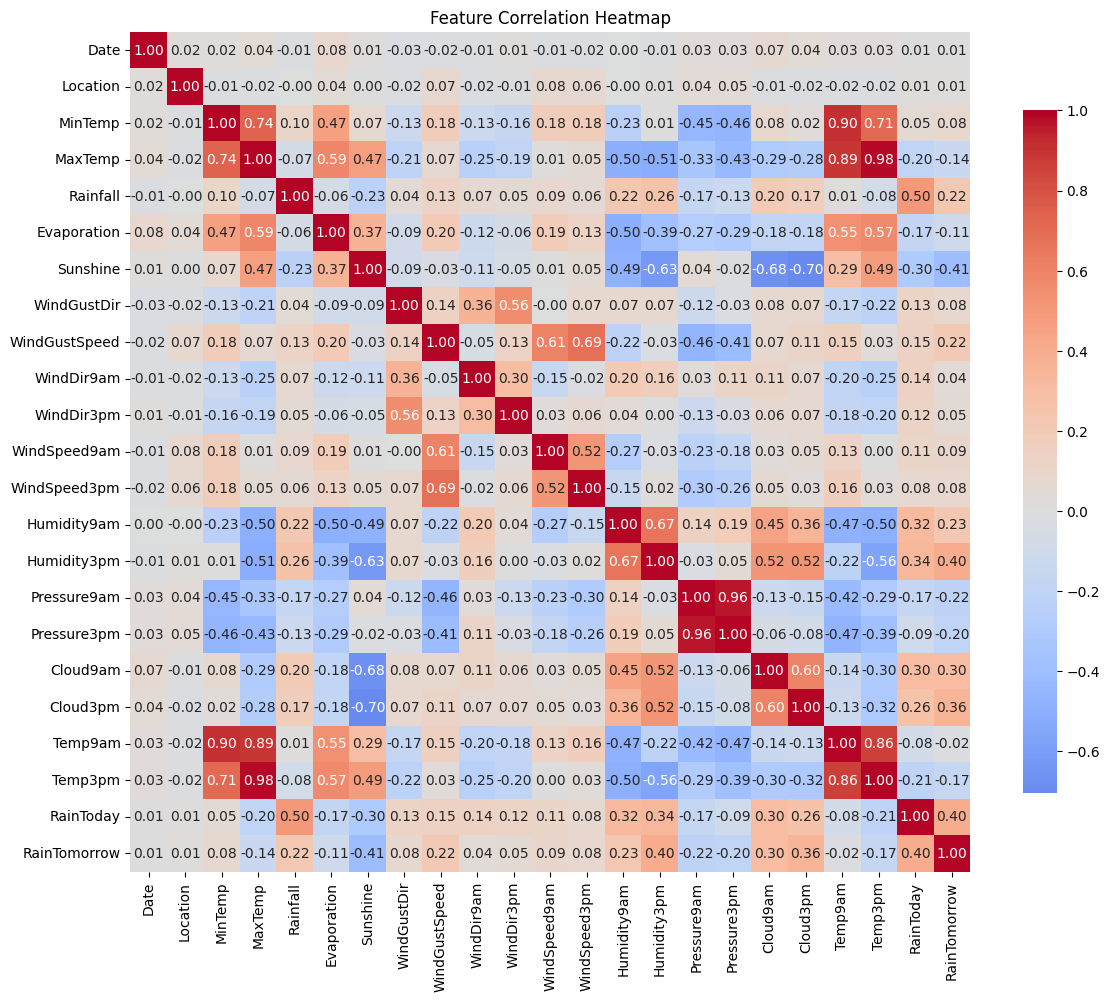

Top 10 features correlated with RainTomorrow:
RainTomorrow     1.000000
RainToday        0.404622
Humidity3pm      0.397160
Cloud3pm         0.356059
Cloud9am         0.301263
Humidity9am      0.230747
Rainfall         0.223487
WindGustSpeed    0.216463
WindSpeed9am     0.093878
WindSpeed3pm     0.084738
Name: RainTomorrow, dtype: float64

Bottom 10 features correlated with RainTomorrow:
WindDir9am     0.035575
Location       0.010202
Date           0.005672
Temp9am       -0.020539
Evaporation   -0.105260
MaxTemp       -0.141733
Temp3pm       -0.169035
Pressure3pm   -0.197110
Pressure9am   -0.215554
Sunshine      -0.405503
Name: RainTomorrow, dtype: float64

Selected 13 features with |correlation| > 0.1


In [6]:
def select_features_by_correlation(df, target_col , threshold=0.1):
    """
    Select features based on correlation with target variable
    """
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    target_corr = corr_matrix[target_col].sort_values(ascending=False)

    print(f"Top 10 features correlated with {target_col}:")
    print(target_corr.head(10))

    print(f"\nBottom 10 features correlated with {target_col}:")
    print(target_corr.tail(10))

    selected_features = target_corr[abs(target_corr) > threshold].index.tolist()
    selected_features.remove(target_col)  

    print(f"\nSelected {len(selected_features)} features with |correlation| > {threshold}")

    return selected_features, corr_matrix

selected_features, corr_matrix = select_features_by_correlation(df, 'RainTomorrow', threshold=0.1)


### 6. Data Preprocessing: Dropping Features
We drop columns that are irrelevant, redundant, or highly correlated with others to simplify the model and prevent multicollinearity.


In [7]:
df.drop(['Temp9am','Date','Location','WindDir9am','WindDir3pm','WindGustDir','MinTemp','WindSpeed3pm','WindSpeed9am','WindGustSpeed'], axis=1, inplace=True)
df


,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow
0,22.9,0.6,NaN,NaN,71.0,22.0,1007.7,1007.1,8.0,NaN,21.8,0,0
1,25.1,0.0,NaN,NaN,44.0,25.0,1010.6,1007.8,NaN,NaN,24.3,0,0
2,25.7,0.0,NaN,NaN,38.0,30.0,1007.6,1008.7,NaN,2.0,23.2,0,0
3,28.0,0.0,NaN,NaN,45.0,16.0,1017.6,1012.8,NaN,NaN,26.5,0,0
4,32.3,1.0,NaN,NaN,82.0,33.0,1010.8,1006.0,7.0,8.0,29.7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,23.4,0.0,NaN,NaN,51.0,24.0,1024.6,1020.3,NaN,NaN,22.4,0,0
145456,25.3,0.0,NaN,NaN,56.0,21.0,1023.5,1019.1,NaN,NaN,24.5,0,0
145457,26.9,0.0,NaN,NaN,53.0,24.0,1021.0,1016.8,NaN,NaN,26.1,0,0
145458,27.0,0.0,NaN,NaN,51.0,24.0,1019.4,1016.5,3.0,2.0,26.0,0,0


We drop any duplicated rows and clear out rows with missing values (NaNs) to ensure data quality before training.


In [8]:
df = df.drop_duplicates()
df.dropna(inplace = True)
df

C:\Users\Yousef_Osama\AppData\Local\Temp\ipykernel_15368\2431079253.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace = True)


,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow
6049,35.2,0.0,12.0,12.3,20.0,13.0,1006.3,1004.4,2.0,5.0,33.4,0,0
6050,28.9,0.0,14.8,13.0,30.0,8.0,1012.9,1012.1,1.0,1.0,27.0,0,0
6052,37.6,0.0,10.8,10.6,42.0,22.0,1012.3,1009.2,1.0,6.0,34.9,0,0
6053,38.4,0.0,11.4,12.2,37.0,22.0,1012.7,1009.1,1.0,5.0,35.6,0,0
6054,41.0,0.0,11.2,8.4,19.0,15.0,1010.7,1007.4,1.0,6.0,37.6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142298,33.4,0.0,6.0,11.0,63.0,32.0,1013.9,1010.5,0.0,1.0,32.3,0,0
142299,32.6,0.0,7.6,8.6,56.0,28.0,1014.6,1011.2,7.0,0.0,32.0,0,0
142300,32.8,0.0,5.6,11.0,46.0,23.0,1015.3,1011.8,0.0,0.0,32.1,0,0
142301,31.8,0.0,6.2,10.6,62.0,58.0,1014.9,1010.7,1.0,1.0,29.2,0,0


We call our feature selection function against the target variable `RainTomorrow` to find the most relevant features.


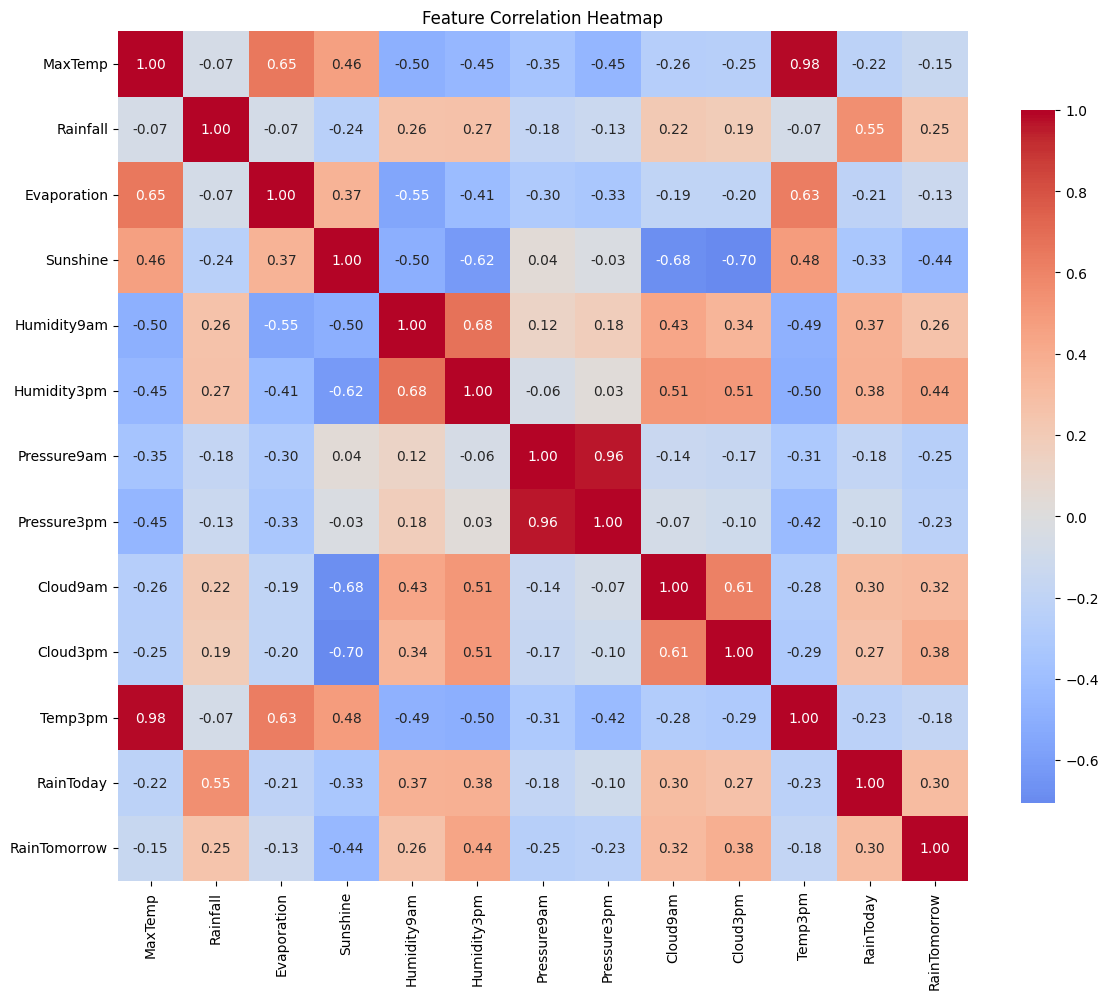

Top 10 features correlated with RainTomorrow:
RainTomorrow    1.000000
Humidity3pm     0.438324
Cloud3pm        0.384087
Cloud9am        0.316426
RainToday       0.304529
Humidity9am     0.261214
Rainfall        0.248053
Evaporation    -0.127513
MaxTemp        -0.145756
Temp3pm        -0.181644
Name: RainTomorrow, dtype: float64

Bottom 10 features correlated with RainTomorrow:
Cloud9am       0.316426
RainToday      0.304529
Humidity9am    0.261214
Rainfall       0.248053
Evaporation   -0.127513
MaxTemp       -0.145756
Temp3pm       -0.181644
Pressure3pm   -0.225680
Pressure9am   -0.250775
Sunshine      -0.442159
Name: RainTomorrow, dtype: float64

Selected 12 features with |correlation| > 0.1


In [9]:
selected_features, corr_matrix = select_features_by_correlation(df, 'RainTomorrow', threshold=0.1)

### 7. Train-Test Split
We split the dataset into features (`x`) and the target variable (`y`), followed by splitting the data into a 90% training set and 10% testing set.


In [10]:
x = df
y = df['RainTomorrow']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, random_state=42)

### 8. Model Training
We initialize the `LogisticRegression` model and fit it to our training data.


In [11]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### 9. Model Prediction
With the model trained, we make predictions on the testing dataset.


In [12]:
y_pred = lr.predict(x_test)

### 10. Model Evaluation
Finally, we evaluate the model's performance by examining appropriate classification metrics such as overall classification Accuracy, Precision, Recall, F1-Score (via classification report) and the Confusion Matrix.


In [13]:
# Calculate metrics
acc = accuracy_score(y_test, y_pred) * 100

print(f"Accuracy: {acc:.2f}%")

# The classification report gives Precision, Recall, and F1-score for each class
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# The confusion matrix highlights True Positives, False Positives, etc.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 92.82%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      4862
           1       0.87      0.78      0.83      1344
           2       0.00      0.00      0.00         8

    accuracy                           0.93      6214
   macro avg       0.60      0.58      0.59      6214
weighted avg       0.93      0.93      0.93      6214


Confusion Matrix:
[[4713  149    0]
 [ 289 1055    0]
 [   0    8    0]]


c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha